In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve

In [2]:
data = pd.read_csv('data_bin.csv')
print("Розмір датасету:", data.shape)
data.head()

Розмір датасету: (944, 32)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,sem,PASSED
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,-2.302585,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,2.208274,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,2.493205,True
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,2.646175,True
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,2.406945,True


In [3]:
print("Інформація про дані:")
data.info()
print("\nКількість пропусків:", data.isnull().sum().sum())

Інформація про дані:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 32 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   school      944 non-null    object 
 1   sex         944 non-null    object 
 2   age         944 non-null    int64  
 3   address     944 non-null    object 
 4   famsize     944 non-null    object 
 5   Pstatus     944 non-null    object 
 6   Medu        944 non-null    int64  
 7   Fedu        944 non-null    int64  
 8   Mjob        944 non-null    object 
 9   Fjob        944 non-null    object 
 10  reason      944 non-null    object 
 11  guardian    944 non-null    object 
 12  traveltime  944 non-null    int64  
 13  studytime   944 non-null    int64  
 14  failures    944 non-null    int64  
 15  schoolsup   944 non-null    object 
 16  famsup      944 non-null    object 
 17  paid        944 non-null    object 
 18  activities  944 non-null    object 
 19  nursery 

In [4]:
print("Описова статистика числових ознак:")
data.describe()

Описова статистика числових ознак:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,sem
count,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000,944.000000
mean,16.688559,2.636653,2.404661,1.507415,1.985169,0.253178,3.940678,3.192797,3.145127,1.475636,2.282839,3.527542,4.385593,2.284653
std,1.204638,1.129181,1.098258,0.723744,0.832653,0.645147,0.907538,1.028188,1.137949,0.877091,1.268545,1.434791,6.331564,0.679939
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-2.302585
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,2.208274
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,2.406945
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,2.572612
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,2.949688


Розподіл цільової змінної PASSED:
PASSED
True     612
False    332
Name: count, dtype: int64
Частка True: 0.65


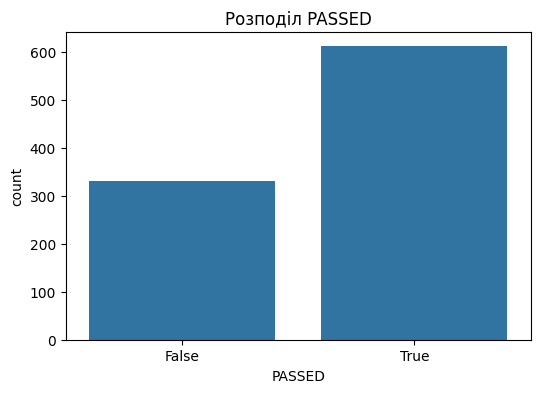

In [5]:
print("Розподіл цільової змінної PASSED:")
print(data['PASSED'].value_counts())
print(f"Частка True: {data['PASSED'].mean():.2f}")

plt.figure(figsize=(6,4))
sns.countplot(data=data, x='PASSED')
plt.title("Розподіл PASSED")
plt.show()

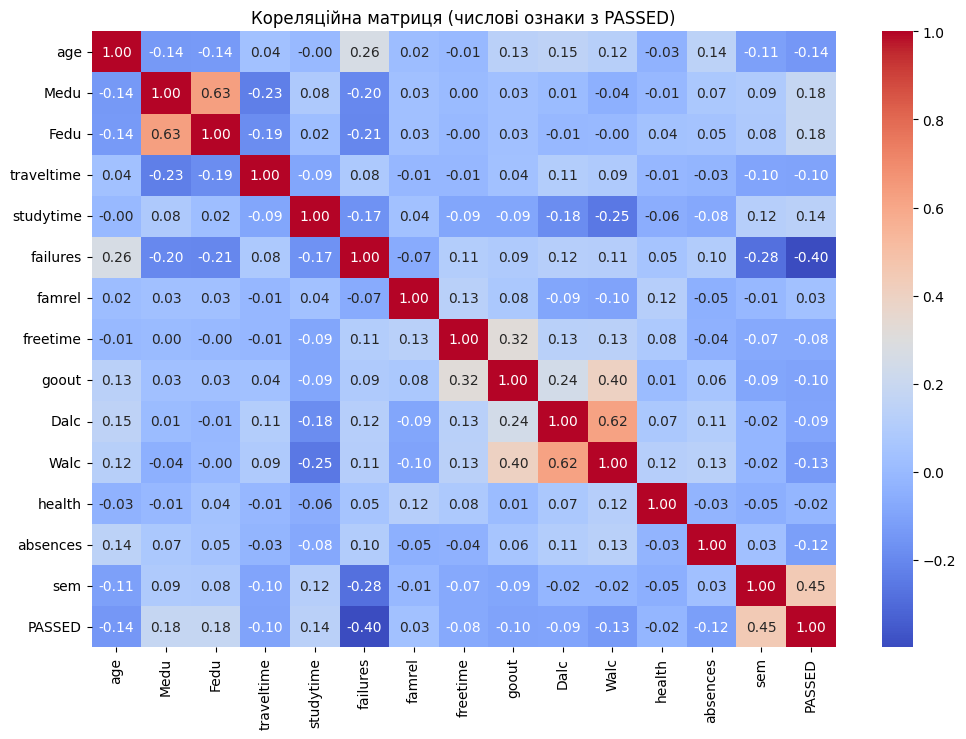

In [7]:
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
plt.figure(figsize=(12,8))
corr = data[numeric_cols + ['PASSED']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Кореляційна матриця (числові ознаки з PASSED)")
plt.show()

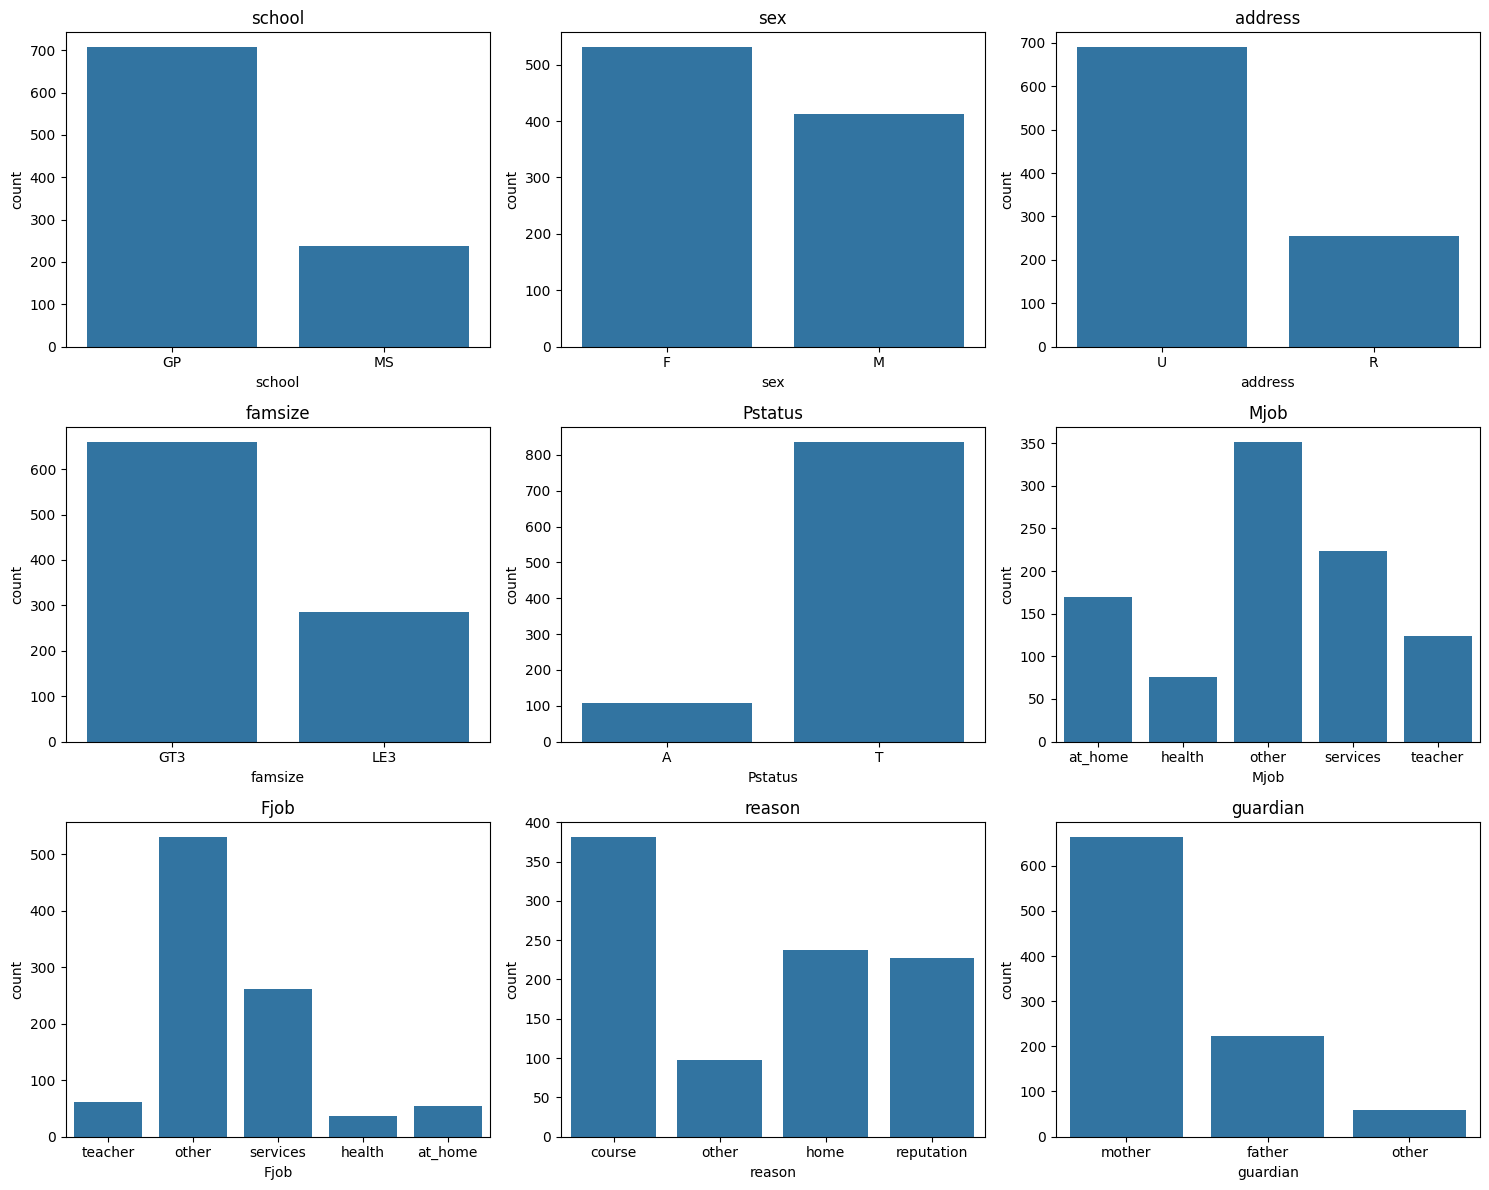

In [8]:
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(15,12))
for i, col in enumerate(categorical_cols[:9]):
    sns.countplot(data=data, x=col, ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.show()

In [9]:
X = data.drop('PASSED', axis=1)
y = data['PASSED']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Розмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

Розмір тренувальної вибірки: (755, 31)
Розмір тестової вибірки: (189, 31)


In [10]:
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числові ознаки:", num_features)

X_train_num = X_train[num_features]
X_test_num = X_test[num_features]

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

Числові ознаки: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'sem']


In [11]:
lr = LogisticRegression(max_iter=1000)
param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['saga']
}
grid = GridSearchCV(lr, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_num_scaled, y_train)

best_lr = grid.best_estimator_
y_pred = best_lr.predict(X_test_num_scaled)
acc = accuracy_score(y_test, y_pred)

print("\nЗавдання 2. Логістична регресія (числові ознаки)")
print(f"Найкращі параметри: {grid.best_params_}")
print(f"Точність (accuracy) на тесті: {acc:.4f}")

C:\Users\ProBook\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ProBook\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



Завдання 2. Логістична регресія (числові ознаки)
Найкращі параметри: {'C': 10, 'penalty': 'l1', 'solver': 'saga'}
Точність (accuracy) на тесті: 0.8889


In [12]:
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

In [13]:
lr_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(solver='saga', max_iter=1000))
])

lr_params = {
    'clf__penalty': ['l1', 'l2', 'elasticnet'],
    'clf__C': [0.01, 0.1, 1, 10, 100]
}

lr_grid = GridSearchCV(lr_pipe, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)

best_lr_all = lr_grid.best_estimator_
y_pred_lr = best_lr_all.predict(X_test)
y_proba_lr = best_lr_all.predict_proba(X_test)[:,1]

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("\nLogisticRegression (saga) на всіх ознаках")
print(f"Найкращі параметри: {lr_grid.best_params_}")
print(f"Accuracy: {acc_lr:.4f}, Precision: {prec_lr:.4f}, Recall: {rec_lr:.4f}, F1: {f1_lr:.4f}, AUC-ROC: {auc_lr:.4f}")

C:\Users\ProBook\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ProBook\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(



LogisticRegression (saga) на всіх ознаках
Найкращі параметри: {'clf__C': 1, 'clf__penalty': 'l1'}
Accuracy: 0.8783, Precision: 0.8623, Recall: 0.9675, F1: 0.9119, AUC-ROC: 0.9618


In [14]:
sgd_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', SGDClassifier(loss='log_loss', max_iter=1000, random_state=42))
])

sgd_params = {
    'clf__penalty': ['l2', 'l1', 'elasticnet'],
    'clf__alpha': [0.0001, 0.001, 0.01, 0.1],
    'clf__l1_ratio': [0.15, 0.5, 0.85],
    'clf__learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive']
}

sgd_grid = GridSearchCV(sgd_pipe, sgd_params, cv=5, scoring='accuracy', n_jobs=-1)
sgd_grid.fit(X_train, y_train)

best_sgd = sgd_grid.best_estimator_
y_pred_sgd = best_sgd.predict(X_test)
y_proba_sgd = best_sgd.predict_proba(X_test)[:,1]

acc_sgd = accuracy_score(y_test, y_pred_sgd)
prec_sgd = precision_score(y_test, y_pred_sgd)
rec_sgd = recall_score(y_test, y_pred_sgd)
f1_sgd = f1_score(y_test, y_pred_sgd)
auc_sgd = roc_auc_score(y_test, y_proba_sgd)

print("\nSGDClassifier (log_loss) на всіх ознаках")
print(f"Найкращі параметри: {sgd_grid.best_params_}")
print(f"Accuracy: {acc_sgd:.4f}, Precision: {prec_sgd:.4f}, Recall: {rec_sgd:.4f}, F1: {f1_sgd:.4f}, AUC-ROC: {auc_sgd:.4f}")


SGDClassifier (log_loss) на всіх ознаках
Найкращі параметри: {'clf__alpha': 0.01, 'clf__l1_ratio': 0.15, 'clf__learning_rate': 'optimal', 'clf__penalty': 'l1'}
Accuracy: 0.9101, Precision: 0.9015, Recall: 0.9675, F1: 0.9333, AUC-ROC: 0.9643


In [15]:
print("\nПорівняння моделей (тестова вибірка):")
print(f"{'Модель':<30} {'Acc':<8} {'Prec':<8} {'Rec':<8} {'F1':<8} {'AUC':<8}")
print("-" * 70)
print(f"{'LogisticRegression (числові)':<30} {acc:<8.4f} {'-':<8} {'-':<8} {'-':<8} {'-':<8}")
print(f"{'LogisticRegression (всі)':<30} {acc_lr:<8.4f} {prec_lr:<8.4f} {rec_lr:<8.4f} {f1_lr:<8.4f} {auc_lr:<8.4f}")
print(f"{'SGDClassifier (всі)':<30} {acc_sgd:<8.4f} {prec_sgd:<8.4f} {rec_sgd:<8.4f} {f1_sgd:<8.4f} {auc_sgd:<8.4f}")

if auc_lr >= auc_sgd:
    best_model = best_lr_all
    best_name = "LogisticRegression (saga)"
    best_proba = y_proba_lr
    best_pred = y_pred_lr
else:
    best_model = best_sgd
    best_name = "SGDClassifier"
    best_proba = y_proba_sgd
    best_pred = y_pred_sgd

print(f"\nНайкраща модель за AUC-ROC: {best_name} (AUC = {max(auc_lr, auc_sgd):.4f})")


Порівняння моделей (тестова вибірка):
Модель                         Acc      Prec     Rec      F1       AUC     
----------------------------------------------------------------------
LogisticRegression (числові)   0.8889   -        -        -        -       
LogisticRegression (всі)       0.8783   0.8623   0.9675   0.9119   0.9618  
SGDClassifier (всі)            0.9101   0.9015   0.9675   0.9333   0.9643  

Найкраща модель за AUC-ROC: SGDClassifier (AUC = 0.9643)


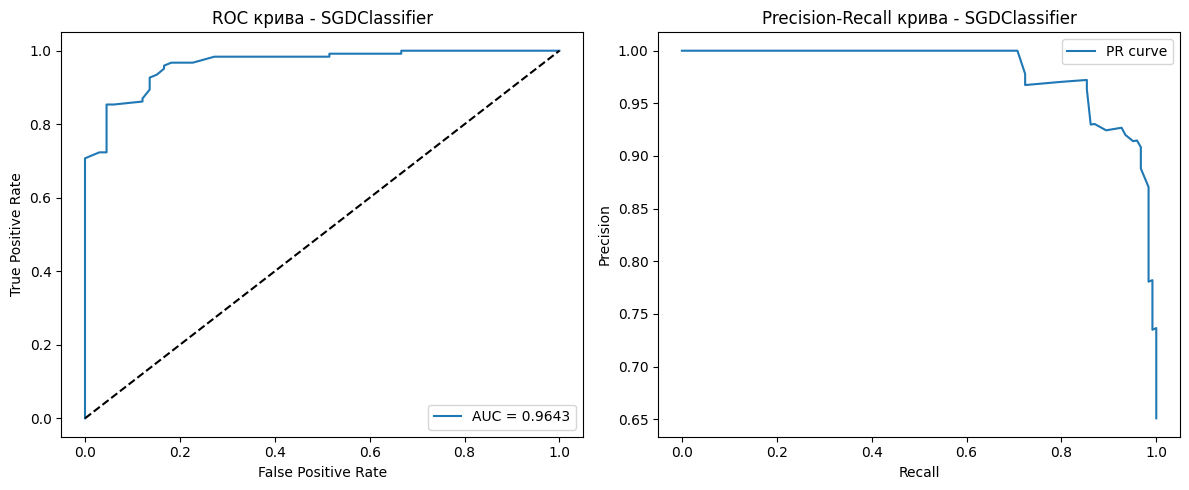

In [16]:
fpr, tpr, _ = roc_curve(y_test, best_proba)
prec, rec, _ = precision_recall_curve(y_test, best_proba)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, best_proba):.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC крива - {best_name}')
plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, label=f'PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall крива - {best_name}')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
predict_df = pd.read_csv('predict.csv')
best_clf_model_predictions = best_model.predict(predict_df)
best_clf_model_predict_proba = best_model.predict_proba(predict_df)

print("Перші 10 прогнозів (клас):", best_clf_model_predictions[:10])
print("Перші 10 ймовірностей (клас 1):", best_clf_model_predict_proba[:10,1])

Перші 10 прогнозів (клас): [False False False False False  True  True  True  True False]
Перші 10 ймовірностей (клас 1): [9.11829339e-24 3.75449936e-02 1.20156931e-01 1.91736791e-01
 2.92399594e-03 9.90419322e-01 7.19558505e-01 8.84872000e-01
 9.91993504e-01 1.39415642e-03]


In [18]:
for t in zip(best_clf_model_predictions[:5], best_clf_model_predict_proba[:5,1]):
    print(*t)

False 9.118293385586883e-24
False 0.03754499364957375
False 0.1201569305539417
False 0.1917367914928468
False 0.0029239959367003683


In [19]:
pd.DataFrame(zip(best_clf_model_predictions, best_clf_model_predict_proba[:,1]), 
             columns=['preds', 'probas']).to_csv('predictions_clf.csv', index=False)
print("Файл predictions_clf.csv створено.")

Файл predictions_clf.csv створено.
